# IMDB Market Trend Analysis Dashboard

**Author:** Sunanda Guha  
**Tools:** Python, Pandas, Matplotlib, Kaggle dataset, Tableau-ready exports

## Goal
Analyze movie market trends using real IMDB-style data and create clean output files that can be used in Tableau or Power BI.

## Business Questions
1. Which genres have the highest average ratings?
2. Which genres receive the most audience votes?
3. How have ratings changed over time?
4. What is the relationship between votes, rating, and runtime?
5. Which movies look strongest from a market trend perspective?

## Step 1: Install and import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import files

## Step 2: Load real data

### Option A — Recommended for Colab
Download a real IMDB dataset from Kaggle, for example:

**Kaggle Dataset:** `https://www.kaggle.com/datasets/PromptCloudHQ/imdb-data`

In [4]:
df = pd.read_csv('/content/sample_data/IMDB-Movie-Data.csv')
df.head()

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


## Step 3: Inspect the data

In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())
display(df.info())
display(df.describe(include="all"))

Shape: (1000, 12)

Columns:
['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year', 'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue (Millions)', 'Metascore']


,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


None

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000,1000,1000,1000,1000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
unique,NaN,999,207,1000,644,996,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,The Host,"Action,Adventure,Sci-Fi",A stuffy businessman finds himself trapped ins...,Ridley Scott,"Jennifer Lawrence, Josh Hutcherson, Liam Hemsw...",NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,2,50,1,8,2,NaN,NaN,NaN,NaN,NaN,NaN
mean,500.500000,NaN,NaN,NaN,NaN,NaN,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,NaN,NaN,NaN,NaN,NaN,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,NaN,NaN,NaN,NaN,NaN,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,NaN,NaN,NaN,NaN,NaN,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,NaN,NaN,NaN,NaN,NaN,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,NaN,NaN,NaN,NaN,NaN,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000


## Step 4: Standardize column names

Different IMDB datasets use slightly different column names.  
This cell tries to make the names consistent.

In [6]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

print(df.columns.tolist())

['rank', 'title', 'genre', 'description', 'director', 'actors', 'year', 'runtime_minutes', 'rating', 'votes', 'revenue_millions', 'metascore']


## Step 5: Clean and prepare data

In [7]:
# Try to detect common columns
title_col = "title" if "title" in df.columns else df.columns[0]
genre_col = "genre" if "genre" in df.columns else None
year_col = "year" if "year" in df.columns else None
rating_col = "rating" if "rating" in df.columns else None
votes_col = "votes" if "votes" in df.columns else None

# Runtime may appear as runtime_minutes or runtime
runtime_candidates = [c for c in df.columns if "runtime" in c]
runtime_col = runtime_candidates[0] if runtime_candidates else None

print("Detected columns:")
print("Title:", title_col)
print("Genre:", genre_col)
print("Year:", year_col)
print("Rating:", rating_col)
print("Votes:", votes_col)
print("Runtime:", runtime_col)

clean_df = df.copy()

# Convert numeric columns
for col in [year_col, rating_col, votes_col, runtime_col]:
    if col is not None:
        clean_df[col] = (
            clean_df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.extract(r"(\d+\.?\d*)")[0]
        )
        clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

# Drop rows missing important fields
required_cols = [c for c in [title_col, genre_col, year_col, rating_col] if c is not None]
clean_df = clean_df.dropna(subset=required_cols)
clean_df = clean_df.drop_duplicates()

print("Cleaned shape:", clean_df.shape)
display(clean_df.head())

Detected columns:
Title: title
Genre: genre
Year: year
Rating: rating
Votes: votes
Runtime: runtime_minutes
Cleaned shape: (1000, 12)


,rank,title,genre,description,director,actors,year,runtime_minutes,rating,votes,revenue_millions,metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


## Step 6: Create genre-level analysis

Some movies have multiple genres separated by commas.  
This step splits them so each genre can be analyzed separately.

In [8]:
if genre_col is None:
    raise ValueError("Genre column was not found. Please check your dataset column names.")

genre_df = clean_df.copy()
genre_df[genre_col] = genre_df[genre_col].astype(str).str.split(",")
genre_df = genre_df.explode(genre_col)
genre_df[genre_col] = genre_df[genre_col].str.strip()

agg_dict = {
    "movie_count": (title_col, "count")
}

if rating_col:
    agg_dict["avg_rating"] = (rating_col, "mean")
if votes_col:
    agg_dict["total_votes"] = (votes_col, "sum")
if runtime_col:
    agg_dict["avg_runtime"] = (runtime_col, "mean")

genre_summary = (
    genre_df.groupby(genre_col)
    .agg(**agg_dict)
    .reset_index()
    .sort_values("movie_count", ascending=False)
)

display(genre_summary.head(10))

,genre,movie_count,avg_rating,total_votes,avg_runtime
6,Drama,513,6.953801,74784098,116.635478
0,Action,303,6.614521,71435768,116.739274
4,Comedy,279,6.647670,39524025,105.899642
1,Adventure,259,6.772201,66819104,117.698842
17,Thriller,195,6.593333,31142039,111.769231
5,Crime,150,6.786667,26340107,115.413333
14,Romance,141,6.685816,17571068,113.007092
15,Sci-Fi,120,6.716667,35344598,116.391667
10,Horror,119,6.089916,10466804,101.563025
13,Mystery,106,6.886792,19147305,115.000000


## Step 7: Yearly trend analysis

In [9]:
if year_col is None:
    raise ValueError("Year column was not found.")

year_agg = {"movie_count": (title_col, "count")}

if rating_col:
    year_agg["avg_rating"] = (rating_col, "mean")
if votes_col:
    year_agg["total_votes"] = (votes_col, "sum")

year_summary = (
    clean_df.groupby(year_col)
    .agg(**year_agg)
    .reset_index()
    .sort_values(year_col)
)

display(year_summary.tail(10))

,year,movie_count,avg_rating,total_votes
1,2007,53,7.133962,12949545
2,2008,52,6.784615,14326280
3,2009,51,6.960784,13044813
4,2010,60,6.826667,15166939
5,2011,63,6.838095,15169789
6,2012,64,6.925000,18254470
7,2013,91,6.812088,19933518
8,2014,98,6.837755,19985162
9,2015,127,6.602362,14697230
10,2016,297,6.436700,14431751


## Step 8: Visualizations

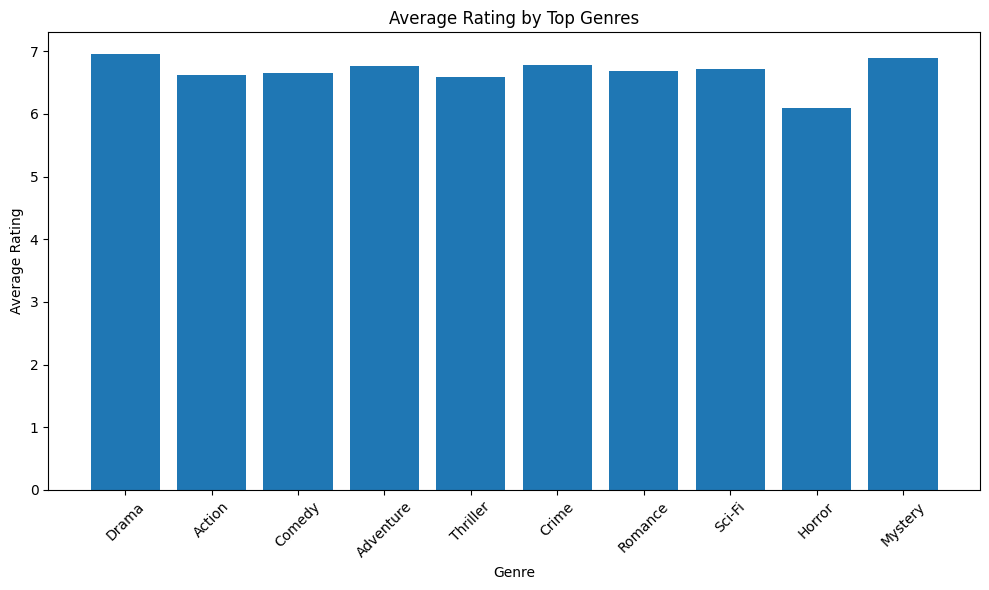

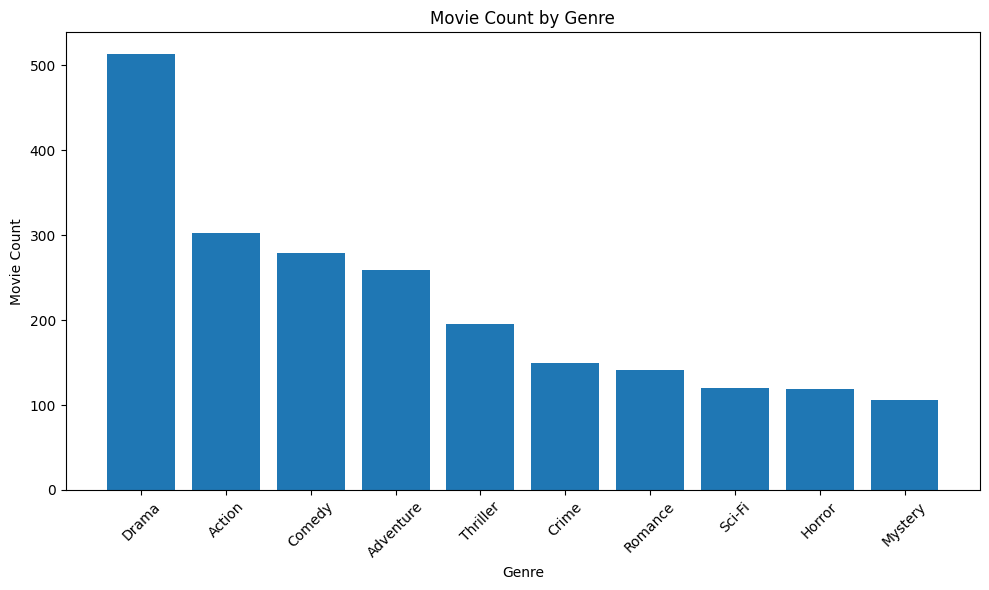

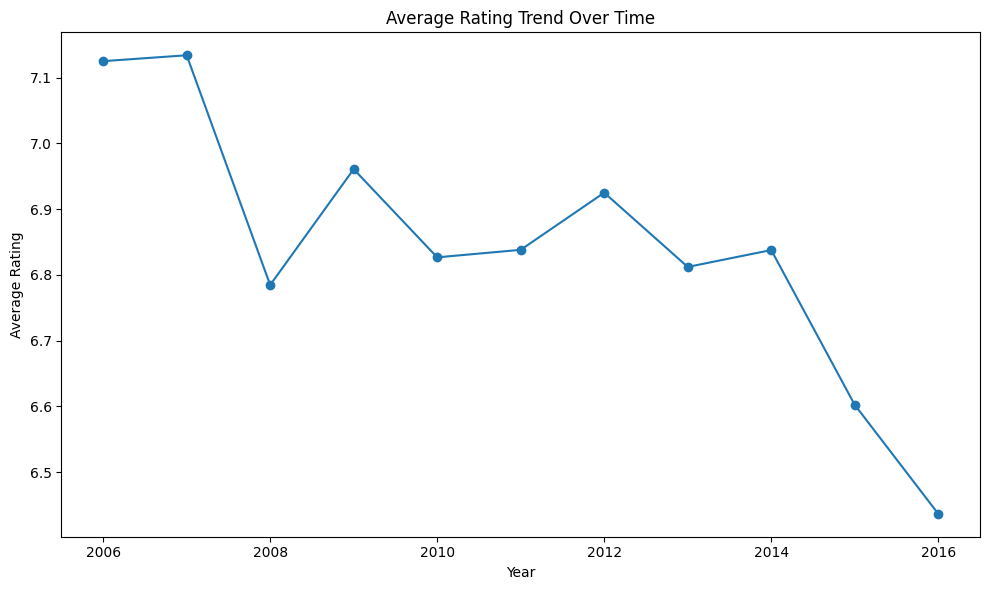

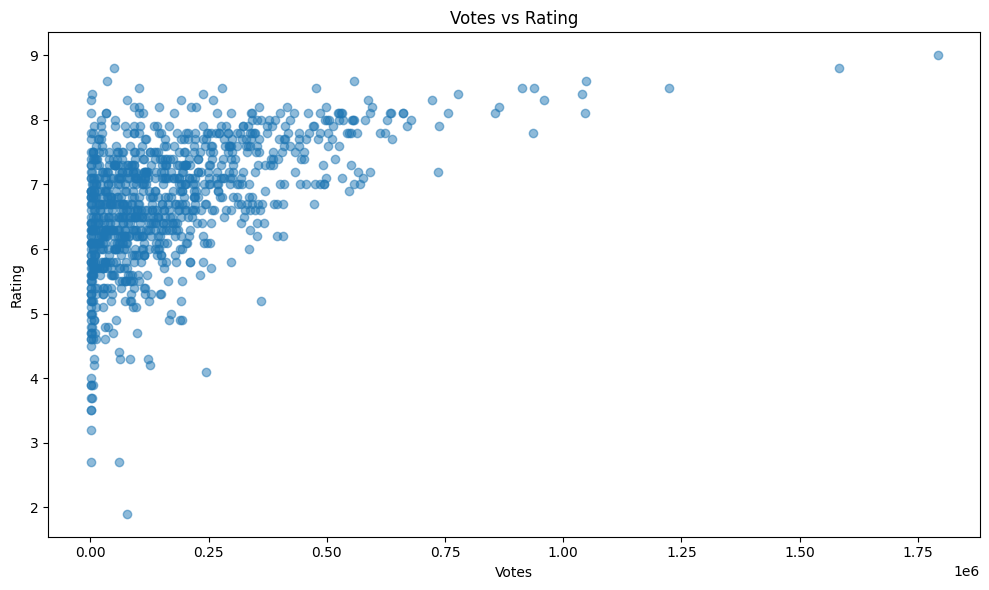

In [10]:
# Average rating by genre
if rating_col:
    top_genres = genre_summary.sort_values("movie_count", ascending=False).head(10)
    plt.figure(figsize=(10, 6))
    plt.bar(top_genres[genre_col], top_genres["avg_rating"])
    plt.title("Average Rating by Top Genres")
    plt.xlabel("Genre")
    plt.ylabel("Average Rating")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Movie count by genre
top_genres_count = genre_summary.sort_values("movie_count", ascending=False).head(10)
plt.figure(figsize=(10, 6))
plt.bar(top_genres_count[genre_col], top_genres_count["movie_count"])
plt.title("Movie Count by Genre")
plt.xlabel("Genre")
plt.ylabel("Movie Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Rating trend by year
if rating_col:
    plt.figure(figsize=(10, 6))
    plt.plot(year_summary[year_col], year_summary["avg_rating"], marker="o")
    plt.title("Average Rating Trend Over Time")
    plt.xlabel("Year")
    plt.ylabel("Average Rating")
    plt.tight_layout()
    plt.show()

# Votes vs Rating
if votes_col and rating_col:
    plt.figure(figsize=(10, 6))
    plt.scatter(clean_df[votes_col], clean_df[rating_col], alpha=0.5)
    plt.title("Votes vs Rating")
    plt.xlabel("Votes")
    plt.ylabel("Rating")
    plt.tight_layout()
    plt.show()

## Step 9: Business insights summary

In [11]:
print("BUSINESS INSIGHTS")
print("-----------------")

if rating_col:
    best_genre = genre_summary.sort_values("avg_rating", ascending=False).iloc[0]
    print(f"1. Highest-rated genre: {best_genre[genre_col]} with average rating {best_genre['avg_rating']:.2f}")

most_common_genre = genre_summary.sort_values("movie_count", ascending=False).iloc[0]
print(f"2. Most common genre: {most_common_genre[genre_col]} with {int(most_common_genre['movie_count'])} movies")

if votes_col:
    most_engaged_genre = genre_summary.sort_values("total_votes", ascending=False).iloc[0]
    print(f"3. Highest audience engagement: {most_engaged_genre[genre_col]} with {int(most_engaged_genre['total_votes'])} votes")

print("4. Recommendation: Use genre-level performance and audience engagement to guide content strategy and dashboard storytelling.")

BUSINESS INSIGHTS
-----------------
1. Highest-rated genre: War with average rating 7.35
2. Most common genre: Drama with 513 movies
3. Highest audience engagement: Drama with 74784098 votes
4. Recommendation: Use genre-level performance and audience engagement to guide content strategy and dashboard storytelling.


## Step 10: Export files for Tableau / GitHub

In [12]:
clean_df.to_csv("cleaned_imdb_data.csv", index=False)
genre_summary.to_csv("imdb_genre_summary.csv", index=False)
year_summary.to_csv("imdb_year_summary.csv", index=False)

print("Exported:")
print("- cleaned_imdb_data.csv")
print("- imdb_genre_summary.csv")
print("- imdb_year_summary.csv")

files.download("cleaned_imdb_data.csv")
files.download("imdb_genre_summary.csv")
files.download("imdb_year_summary.csv")

Exported:
- cleaned_imdb_data.csv
- imdb_genre_summary.csv
- imdb_year_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>